<a href="https://colab.research.google.com/github/oluwafemi244/facility-maintenance-energy-decision-support/blob/main/notebooks/03_maintenance_prioritization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Maintenance Prioritization and Resource Allocation Proof of Concept

## Facility Maintenance and Energy Decision-Support Framework

This notebook demonstrates how estimated machine failure probabilities can be combined with facility specific consequence and resource information to support maintenance prioritization.

The failure probabilities used in this notebook were produced during the preceding AI4I proof of concept modeling stage.

The AI4I dataset does not contain facility criticality, expected downtime, maintenance cost, labor requirements, or spare-parts availability. Those variables are therefore simulated in this notebook solely to demonstrate the architecture of the proposed decision-support framework.

No simulated variable is presented as an observation from an actual facility.

The objective of this stage is to demonstrate a transparent process that:

1. combines estimated failure probability with operational consequence;
2. produces a preliminary maintenance priority score;
3. ranks candidate maintenance actions;
4. applies budget, labor, and parts constraints; and
5. identifies a feasible set of maintenance actions under limited resources.

The results remain proof of concept results and are not operational maintenance recommendations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

In [2]:
predictions_url = (
    "https://raw.githubusercontent.com/"
    "oluwafemi244/facility-maintenance-energy-decision-support/"
    "main/results/test_failure_risk_predictions.csv"
)

predictions = pd.read_csv(predictions_url)

print("Prediction results loaded successfully.")
print(f"Rows: {predictions.shape[0]:,}")
print(f"Columns: {predictions.shape[1]}")

predictions.head()

Prediction results loaded successfully.
Rows: 2,000
Columns: 9


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type,Actual Machine Failure,Estimated Failure Probability,Preliminary Risk Band
0,298.9,310.2,2737,8.8,142,L,1,0.876667,Very High
1,303.3,311.3,1350,48.1,32,L,1,0.816667,Very High
2,302.6,310.4,1359,57.2,67,L,1,0.806667,Very High
3,297.5,308.3,2564,12.8,127,L,1,0.780000,Very High
4,301.0,312.2,2710,9.7,143,M,1,0.776667,Very High


In [3]:
print(
    predictions["Estimated Failure Probability"]
    .describe()
)

count    2000.000000
mean        0.028562
std         0.101237
min         0.000000
25%         0.000000
50%         0.000000
75%         0.006667
max         0.876667
Name: Estimated Failure Probability, dtype: float64


In [4]:
print(
    "Minimum probability:",
    predictions["Estimated Failure Probability"].min()
)

print(
    "Maximum probability:",
    predictions["Estimated Failure Probability"].max()
)

Minimum probability: 0.0
Maximum probability: 0.8766666666666667


In [5]:
predictions_sorted = predictions.sort_values(
    "Estimated Failure Probability",
    ascending=False
).reset_index(drop=True)

selected_indices = np.linspace(
    0,
    len(predictions_sorted) - 1,
    60,
    dtype=int
)

portfolio = (
    predictions_sorted
    .iloc[selected_indices]
    .copy()
    .reset_index(drop=True)
)

portfolio["Asset ID"] = [
    f"ASSET-{i:03d}"
    for i in range(1, len(portfolio) + 1)
]

print(f"Demonstration assets created: {len(portfolio)}")

portfolio[
    [
        "Asset ID",
        "Estimated Failure Probability",
        "Actual Machine Failure"
    ]
].head(10)

Demonstration assets created: 60


,Asset ID,Estimated Failure Probability,Actual Machine Failure
0,ASSET-001,0.876667,1
1,ASSET-002,0.510000,1
2,ASSET-003,0.253333,1
3,ASSET-004,0.163333,0
4,ASSET-005,0.110000,0
5,ASSET-006,0.066667,0
6,ASSET-007,0.050000,0
7,ASSET-008,0.036667,0
8,ASSET-009,0.026667,0
9,ASSET-010,0.020000,0


## Simulated Facility Context

The following variables are not contained in the AI4I source dataset.

They are generated solely for this proof of concept so that the project can demonstrate how failure risk estimates could later be combined with facility specific operational and resource information.

The simulated variables are:

- operational criticality;
- expected downtime;
- maintenance cost;
- maintenance labor requirement; and
- spare parts availability.

The simulation is reproducible because a fixed random seed is used.

These values have no claimed relationship to an actual facility.

In [6]:
n_assets = len(portfolio)

portfolio["Operational Criticality"] = rng.integers(
    low=1,
    high=6,
    size=n_assets
)

portfolio["Expected Downtime Hours"] = rng.integers(
    low=4,
    high=73,
    size=n_assets
)

portfolio["Maintenance Cost"] = rng.integers(
    low=1500,
    high=15001,
    size=n_assets
)

portfolio["Labor Hours Required"] = rng.integers(
    low=4,
    high=41,
    size=n_assets
)

portfolio["Spare Parts Available"] = rng.choice(
    [0, 1],
    size=n_assets,
    p=[0.15, 0.85]
)

portfolio[
    [
        "Asset ID",
        "Estimated Failure Probability",
        "Operational Criticality",
        "Expected Downtime Hours",
        "Maintenance Cost",
        "Labor Hours Required",
        "Spare Parts Available"
    ]
].head(10)

,Asset ID,Estimated Failure Probability,Operational Criticality,Expected Downtime Hours,Maintenance Cost,Labor Hours Required,Spare Parts Available
0,ASSET-001,0.876667,1,67,7435,38,1
1,ASSET-002,0.510000,4,55,10524,9,1
2,ASSET-003,0.253333,4,29,10335,22,0
3,ASSET-004,0.163333,3,70,7860,29,1
4,ASSET-005,0.110000,3,32,13044,22,0
5,ASSET-006,0.066667,5,26,9131,20,1
6,ASSET-007,0.050000,1,66,2569,10,1
7,ASSET-008,0.036667,4,29,11828,18,0
8,ASSET-009,0.026667,2,9,9257,12,0
9,ASSET-010,0.020000,1,36,10069,15,1


In [7]:
portfolio["Criticality Normalized"] = (
    portfolio["Operational Criticality"] / 5
)

downtime_min = portfolio["Expected Downtime Hours"].min()
downtime_max = portfolio["Expected Downtime Hours"].max()

portfolio["Downtime Normalized"] = (
    portfolio["Expected Downtime Hours"] - downtime_min
) / (
    downtime_max - downtime_min
)

portfolio[
    [
        "Asset ID",
        "Operational Criticality",
        "Criticality Normalized",
        "Expected Downtime Hours",
        "Downtime Normalized"
    ]
].head()

,Asset ID,Operational Criticality,Criticality Normalized,Expected Downtime Hours,Downtime Normalized
0,ASSET-001,1,0.2,67,0.954545
1,ASSET-002,4,0.8,55,0.772727
2,ASSET-003,4,0.8,29,0.378788
3,ASSET-004,3,0.6,70,1.000000
4,ASSET-005,3,0.6,32,0.424242


## Preliminary Consequence Index

For this proof of concept, operational consequence is represented through two simulated factors:

- operational criticality; and
- expected downtime.

A preliminary consequence index is calculated using:

- 60% operational criticality; and
- 40% expected downtime.

These weights are demonstration assumptions. They are not industry standards and are not presented as validated facility specific weights.

In a practical application, weights would need to reflect the operating objectives, safety requirements, engineering judgment, facility policies, and available evidence applicable to the specific facility.

In [8]:
CRITICALITY_WEIGHT = 0.60
DOWNTIME_WEIGHT = 0.40

portfolio["Consequence Index"] = (
    CRITICALITY_WEIGHT
    * portfolio["Criticality Normalized"]
    +
    DOWNTIME_WEIGHT
    * portfolio["Downtime Normalized"]
)

portfolio[
    [
        "Asset ID",
        "Criticality Normalized",
        "Downtime Normalized",
        "Consequence Index"
    ]
].head()

,Asset ID,Criticality Normalized,Downtime Normalized,Consequence Index
0,ASSET-001,0.2,0.954545,0.501818
1,ASSET-002,0.8,0.772727,0.789091
2,ASSET-003,0.8,0.378788,0.631515
3,ASSET-004,0.6,1.000000,0.760000
4,ASSET-005,0.6,0.424242,0.529697


In [9]:
portfolio["Maintenance Risk Score"] = (
    portfolio["Estimated Failure Probability"]
    * portfolio["Consequence Index"]
)

portfolio["Maintenance Risk Score 0-100"] = (
    portfolio["Maintenance Risk Score"] * 100
)

portfolio = portfolio.sort_values(
    "Maintenance Risk Score",
    ascending=False
).reset_index(drop=True)

portfolio["Priority Rank"] = (
    np.arange(1, len(portfolio) + 1)
)

portfolio[
    [
        "Priority Rank",
        "Asset ID",
        "Estimated Failure Probability",
        "Consequence Index",
        "Maintenance Risk Score 0-100"
    ]
].head(15)

,Priority Rank,Asset ID,Estimated Failure Probability,Consequence Index,Maintenance Risk Score 0-100
0,1,ASSET-001,0.876667,0.501818,43.992727
1,2,ASSET-002,0.510000,0.789091,40.243636
2,3,ASSET-003,0.253333,0.631515,15.998384
3,4,ASSET-004,0.163333,0.760000,12.413333
4,5,ASSET-005,0.110000,0.529697,5.826667
5,6,ASSET-006,0.066667,0.733333,4.888889
6,7,ASSET-007,0.050000,0.495758,2.478788
7,8,ASSET-008,0.036667,0.631515,2.315556
8,9,ASSET-011,0.016667,0.687273,1.145455
9,10,ASSET-009,0.026667,0.270303,0.720808


In [10]:
def priority_category(score):

    if score >= 60:
        return "Critical"

    elif score >= 35:
        return "High"

    elif score >= 15:
        return "Moderate"

    else:
        return "Low"


portfolio["Priority Category"] = (
    portfolio["Maintenance Risk Score 0-100"]
    .apply(priority_category)
)

portfolio["Priority Category"].value_counts()

,count
Priority Category,
Low,57
High,2
Moderate,1


### Priority Category Limitation

The priority thresholds used in this demonstration are illustrative categories created for the proof of concept.

They are not regulatory thresholds, engineering standards, or validated maintenance-action limits.

Their purpose is to demonstrate how a continuous risk score could be translated into an understandable maintenance-priority classification.

Practical thresholds would require facility specific validation.

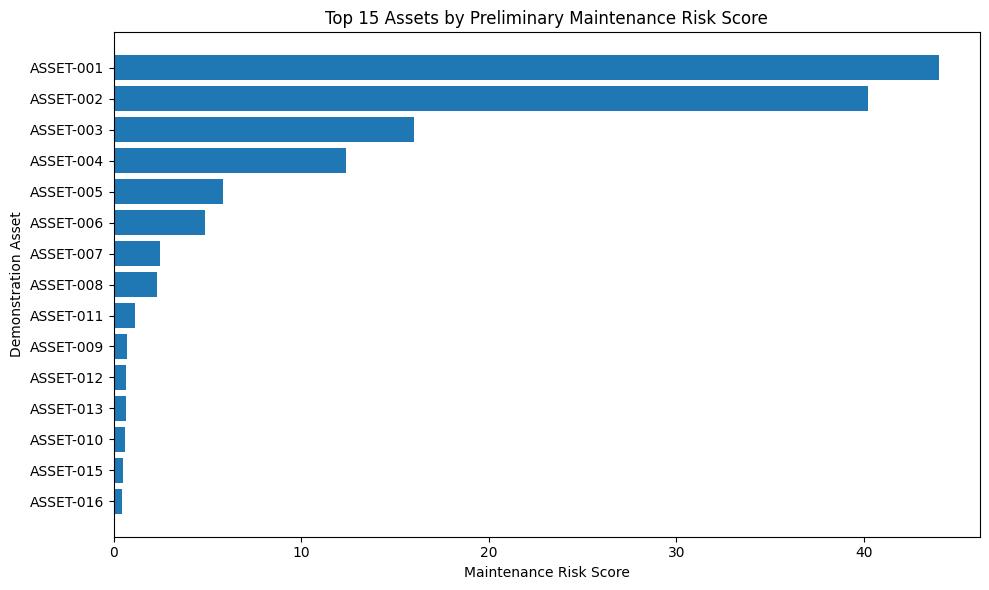

In [11]:
top_15 = portfolio.head(15).copy()

plt.figure(figsize=(10, 6))

plt.barh(
    top_15["Asset ID"][::-1],
    top_15["Maintenance Risk Score 0-100"][::-1]
)

plt.title("Top 15 Assets by Preliminary Maintenance Risk Score")
plt.xlabel("Maintenance Risk Score")
plt.ylabel("Demonstration Asset")
plt.tight_layout()
plt.show()

In [12]:
comparison = portfolio[
    [
        "Asset ID",
        "Estimated Failure Probability",
        "Operational Criticality",
        "Expected Downtime Hours",
        "Consequence Index",
        "Maintenance Risk Score 0-100",
        "Priority Rank"
    ]
].copy()

comparison.head(20)

,Asset ID,Estimated Failure Probability,Operational Criticality,Expected Downtime Hours,Consequence Index,Maintenance Risk Score 0-100,Priority Rank
0,ASSET-001,0.876667,1,67,0.501818,43.992727,1
1,ASSET-002,0.510000,4,55,0.789091,40.243636,2
2,ASSET-003,0.253333,4,29,0.631515,15.998384,3
3,ASSET-004,0.163333,3,70,0.760000,12.413333,4
4,ASSET-005,0.110000,3,32,0.529697,5.826667,5
5,ASSET-006,0.066667,5,26,0.733333,4.888889,6
6,ASSET-007,0.050000,1,66,0.495758,2.478788,7
7,ASSET-008,0.036667,4,29,0.631515,2.315556,8
8,ASSET-011,0.016667,3,58,0.687273,1.145455,9
9,ASSET-009,0.026667,2,9,0.270303,0.720808,10


## Why the Prioritization Layer Matters

Failure probability alone does not determine maintenance priority.

Two assets with similar estimated failure probabilities may have different operational consequences. Conversely, an asset with a lower failure probability may warrant greater attention if its failure would create significantly greater downtime or affect a more critical function.

The proof of concept therefore separates:

**likelihood of failure**

from:

**consequence of failure**

and combines them through a transparent risk calculation.



## Demonstration Resource Constraints

The following maintenance-resource limits are simulated solely for the proof of concept:

- Total maintenance budget: $120,000
- Available maintenance labor: 240 hours
- Maintenance actions requiring unavailable spare parts cannot be selected.

These constraints do not represent an actual facility budget, workforce, or maintenance schedule.

In [13]:
MAINTENANCE_BUDGET = 120000
AVAILABLE_LABOR_HOURS = 240

print(f"Demonstration maintenance budget: ${MAINTENANCE_BUDGET:,.0f}")
print(f"Available labor hours: {AVAILABLE_LABOR_HOURS}")

Demonstration maintenance budget: $120,000
Available labor hours: 240


In [14]:
ranking_candidates = portfolio[
    portfolio["Spare Parts Available"] == 1
].copy()

ranking_candidates = ranking_candidates.sort_values(
    "Maintenance Risk Score",
    ascending=False
)

selected_by_rank = []

running_cost = 0
running_labor = 0

for _, row in ranking_candidates.iterrows():

    new_cost = running_cost + row["Maintenance Cost"]
    new_labor = running_labor + row["Labor Hours Required"]

    if (
        new_cost <= MAINTENANCE_BUDGET
        and
        new_labor <= AVAILABLE_LABOR_HOURS
    ):
        selected_by_rank.append(row["Asset ID"])
        running_cost = new_cost
        running_labor = new_labor

print("Assets selected by simple ranking:", len(selected_by_rank))
print(f"Total cost: ${running_cost:,.0f}")
print(f"Total labor: {running_labor:.0f} hours")

Assets selected by simple ranking: 12
Total cost: $95,572
Total labor: 240 hours


In [15]:
!pip -q install pulp

In [16]:
import pulp

In [17]:
candidates = portfolio.copy()

problem = pulp.LpProblem(
    "Maintenance_Resource_Allocation",
    pulp.LpMaximize
)

decision_variables = {}

for i, row in candidates.iterrows():

    decision_variables[i] = pulp.LpVariable(
        f"maintain_{i}",
        cat="Binary"
    )

In [18]:
problem += pulp.lpSum(
    decision_variables[i]
    * candidates.loc[i, "Maintenance Risk Score"]
    for i in candidates.index
)

In [19]:
problem += (
    pulp.lpSum(
        decision_variables[i]
        * candidates.loc[i, "Maintenance Cost"]
        for i in candidates.index
    )
    <= MAINTENANCE_BUDGET
)

In [20]:
problem += (
    pulp.lpSum(
        decision_variables[i]
        * candidates.loc[i, "Labor Hours Required"]
        for i in candidates.index
    )
    <= AVAILABLE_LABOR_HOURS
)

In [21]:
for i in candidates.index:

    if candidates.loc[i, "Spare Parts Available"] == 0:

        problem += decision_variables[i] == 0

In [22]:
problem.solve(
    pulp.PULP_CBC_CMD(msg=False)
)

print(
    "Optimization status:",
    pulp.LpStatus[problem.status]
)

Optimization status: Optimal


In [23]:
candidates["Selected for Maintenance"] = [
    int(pulp.value(decision_variables[i]))
    for i in candidates.index
]

selected_assets = candidates[
    candidates["Selected for Maintenance"] == 1
].copy()

selected_assets = selected_assets.sort_values(
    "Maintenance Risk Score",
    ascending=False
)

print(
    "Selected maintenance actions:",
    len(selected_assets)
)

print(
    f"Total selected cost: "
    f"${selected_assets['Maintenance Cost'].sum():,.0f}"
)

print(
    f"Total selected labor: "
    f"{selected_assets['Labor Hours Required'].sum():,.0f} hours"
)

print(
    f"Total modeled risk addressed: "
    f"{selected_assets['Maintenance Risk Score 0-100'].sum():.2f}"
)

Selected maintenance actions: 11
Total selected cost: $83,656
Total selected labor: 236 hours
Total modeled risk addressed: 107.77


In [24]:
selected_assets[
    [
        "Asset ID",
        "Priority Rank",
        "Estimated Failure Probability",
        "Operational Criticality",
        "Expected Downtime Hours",
        "Maintenance Risk Score 0-100",
        "Maintenance Cost",
        "Labor Hours Required"
    ]
]

,Asset ID,Priority Rank,Estimated Failure Probability,Operational Criticality,Expected Downtime Hours,Maintenance Risk Score 0-100,Maintenance Cost,Labor Hours Required
0,ASSET-001,1,0.876667,1,67,43.992727,7435,38
1,ASSET-002,2,0.510000,4,55,40.243636,10524,9
3,ASSET-004,4,0.163333,3,70,12.413333,7860,29
5,ASSET-006,6,0.066667,5,26,4.888889,9131,20
6,ASSET-007,7,0.050000,1,66,2.478788,2569,10
8,ASSET-011,9,0.016667,3,58,1.145455,9133,29
10,ASSET-012,11,0.010000,5,17,0.678788,8973,27
11,ASSET-013,12,0.010000,4,35,0.667879,2722,26
12,ASSET-010,13,0.020000,1,36,0.627879,10069,15
15,ASSET-014,16,0.006667,4,12,0.352323,9049,17


In [25]:
rank_selected_df = portfolio[
    portfolio["Asset ID"].isin(selected_by_rank)
]

comparison_results = pd.DataFrame({
    "Method": [
        "Simple Risk Ranking",
        "Constrained Optimization"
    ],

    "Assets Selected": [
        len(rank_selected_df),
        len(selected_assets)
    ],

    "Total Cost": [
        rank_selected_df["Maintenance Cost"].sum(),
        selected_assets["Maintenance Cost"].sum()
    ],

    "Labor Hours": [
        rank_selected_df["Labor Hours Required"].sum(),
        selected_assets["Labor Hours Required"].sum()
    ],

    "Total Risk Score Addressed": [
        rank_selected_df["Maintenance Risk Score 0-100"].sum(),
        selected_assets["Maintenance Risk Score 0-100"].sum()
    ]
})

comparison_results

,Method,Assets Selected,Total Cost,Labor Hours,Total Risk Score Addressed
0,Simple Risk Ranking,12,95572,240,107.766465
1,Constrained Optimization,11,83656,236,107.766465


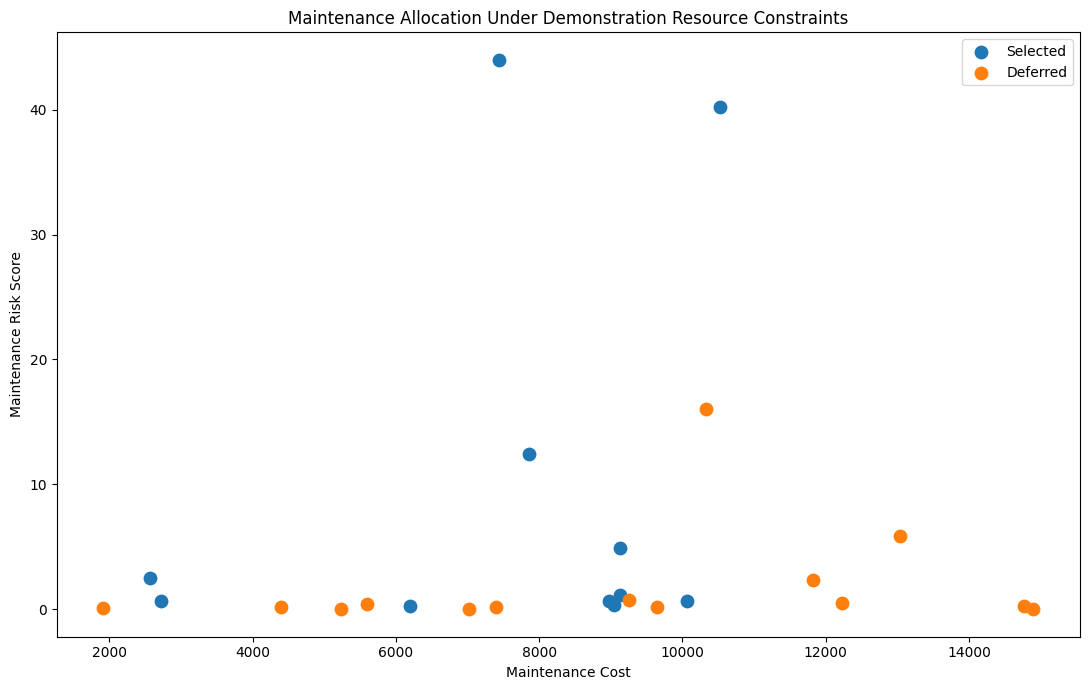

In [31]:
# Use the candidates dataframe because it contains
# the optimization decision: Selected for Maintenance

plot_df = (
    candidates
    .sort_values("Maintenance Risk Score", ascending=False)
    .head(25)
    .copy()
)

plot_df["Allocation Status"] = np.where(
    plot_df["Selected for Maintenance"] == 1,
    "Selected",
    "Deferred"
)

plt.figure(figsize=(11, 7))

for status in ["Selected", "Deferred"]:

    subset = plot_df[
        plot_df["Allocation Status"] == status
    ]

    plt.scatter(
        subset["Maintenance Cost"],
        subset["Maintenance Risk Score 0-100"],
        label=status,
        s=80
    )

plt.title(
    "Maintenance Allocation Under Demonstration Resource Constraints"
)

plt.xlabel("Maintenance Cost")
plt.ylabel("Maintenance Risk Score")
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
simulated_context_columns = [
    "Asset ID",
    "Operational Criticality",
    "Expected Downtime Hours",
    "Maintenance Cost",
    "Labor Hours Required",
    "Spare Parts Available"
]

portfolio[
    simulated_context_columns
].to_csv(
    "/content/simulated_asset_context.csv",
    index=False
)

print("Simulated context file created.")

Simulated context file created.


In [33]:
portfolio.to_csv(
    "/content/maintenance_priority_results.csv",
    index=False
)

selected_assets.to_csv(
    "/content/maintenance_allocation_results.csv",
    index=False
)

comparison_results.to_csv(
    "/content/allocation_method_comparison.csv",
    index=False
)

print("Maintenance prioritization result files created.")

Maintenance prioritization result files created.


## Preliminary Conclusions

This proof of concept demonstrates a preliminary maintenance decision support process that extends beyond failure prediction.

Estimated failure probability was combined with simulated operational criticality and expected downtime to produce a transparent maintenance risk score.

Candidate maintenance actions were then evaluated under simulated budget, labor, and spare-parts constraints.

The analysis also compares a simple priority ranking approach with constrained optimization. This comparison is intended to determine whether explicit resource allocation methods can provide additional value when facilities cannot perform every candidate maintenance action.

All facility context and resource variables in this notebook are simulated and are not represented as observations from an actual facility.

The weighting assumptions, priority categories, maintenance budget, labor availability, and other demonstration parameters are preliminary. They require facility-specific validation before practical use.

This stage establishes the architecture linking:

**failure-risk estimation → operational consequence → maintenance priority → constrained resource allocation**

The next development stages will evaluate sensitivity to the demonstration assumptions, document the validation strategy more formally, and prepare the preliminary technical report for the maintenance proof of concept.